# Can Financial Ratios Predict ESG Scores?
## A Machine Learning Analysis of UK Listed Companies

**Author:** Md Aminul Islam Tushar

**Module:** BUSI 1783: MSc Business Analytics, University of Greenwich

**Data:** FTSE 250 non-financial constituents, 2019–2023 (ORBIS + Refinitiv Eikon)

---

### Research questions

**RQ1** : To what extent can financial ratios predict ESG scores among UK-listed companies?

**RQ2** : Do machine learning models provide better predictive performance than traditional regression?

### Hypotheses

| | Statement |
|---|---|
| H1 | Profitability is positively associated with ESG performance |
| H2 | Leverage is negatively associated with ESG performance |
| H3 | Liquidity is positively associated with ESG performance |
| H4 | Random Forest and XGBoost outperform Multiple Linear Regression |

### A note on evaluation design

ESG scores are highly persistent within firms. A conventional random train/test split would
place the same company on both sides of the partition, allowing tree-based models to recognise
firms rather than learn the financial→ESG relationship. **All splits and cross-validation folds in
this notebook are grouped by firm (ISIN)**, so no company appears in both training and test data.
Section 7 quantifies how much this matters.

In [36]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import (GroupShuffleSplit, GroupKFold,
                                     RandomizedSearchCV, train_test_split,
                                     cross_val_score)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 300,
                     'savefig.bbox': 'tight', 'font.size': 10})

from pathlib import Path
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load and prepare data

In [37]:
df = pd.read_csv('data/final/analytical_dataset.csv')

print(f'Observations : {len(df)}')
print(f'Firms        : {df["ISIN"].nunique()}')
print(f'Years        : {df["Year"].min()}–{df["Year"].max()}')
df.head()

Observations : 389
Firms        : 85
Years        : 2019–2023


,ISIN,Year,TotalAssets,CurrentAssets,Inventory,CurrentLiabilities,Equity,LongTermDebt,ShortTermDebt,NetIncome,...,ROE,DebtToEquity,DebtToAssets,CurrentRatio,QuickRatio,LogTotalAssets,FirmAge,Sector,SectorSection,ESG_Score
0,GB0000055888,2021,592700.0,266200.0,77800.0,190300.0,290400.0,84000.0,71400.0,25200.0,...,0.086777,0.535124,0.262190,1.398844,0.990016,13.292444,35.0,26,C,37.437497
1,GB0000055888,2022,585700.0,249800.0,90000.0,151200.0,303600.0,101500.0,39900.0,21300.0,...,0.070158,0.465744,0.241421,1.652116,1.056878,13.280563,36.0,26,C,42.584585
2,GB0000055888,2023,668700.0,287700.0,80100.0,185400.0,301600.0,150500.0,78700.0,15500.0,...,0.051393,0.759947,0.342755,1.551780,1.119741,13.413091,37.0,26,C,42.328528
3,GB0000904986,2019,3889857.0,3806682.0,3477583.0,869269.0,2921174.0,11923.0,0.0,538554.0,...,0.184362,0.004082,0.003065,4.379176,0.378593,15.173883,41.0,41,F,55.583804
4,GB0000904986,2020,4083600.0,3984300.0,3863000.0,955800.0,2994000.0,14100.0,50000.0,192900.0,...,0.064429,0.021409,0.015697,4.168550,0.257269,15.222490,42.0,41,F,59.260669


### 1.1 Collapse sparse sector categories

Sections with fewer than 10 firm-year observations cannot support reliable dummy estimation
and would produce empty cells in some cross-validation folds. These are merged into 'Other'.

In [38]:
counts = df['SectorSection'].value_counts()
rare = counts[counts < 10].index.tolist()
df['SectorGrouped'] = df['SectorSection'].replace({s: 'Other' for s in rare})

print(f'Collapsed into "Other": {rare}')
print()
print(df['SectorGrouped'].value_counts().to_string())

Collapsed into "Other": ['D', 'E', 'Q']

SectorGrouped
C        105
J         56
G         46
L         35
H         34
F         29
N         29
I         23
M         20
Other     12


In [39]:
# Median-impute the small number of missing firm ages
n_missing = df['FirmAge'].isna().sum()
df['FirmAge'] = df['FirmAge'].fillna(df['FirmAge'].median())
print(f'FirmAge values imputed at median: {n_missing}')

FirmAge values imputed at median: 3


---
## 2. Descriptive statistics: **Table 4.1**

In [40]:
RATIOS   = ['ROA', 'ROE', 'DebtToEquity', 'DebtToAssets', 'CurrentRatio', 'QuickRatio']
CONTROLS = ['LogTotalAssets', 'FirmAge']
TARGET   = 'ESG_Score'

desc = df[RATIOS + CONTROLS + [TARGET]].describe().T
desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(3)
desc.columns = ['N', 'Mean', 'SD', 'Min', 'Q1', 'Median', 'Q3', 'Max']
desc.to_csv(OUT / 'table_4_1_descriptives.csv')
desc

,N,Mean,SD,Min,Q1,Median,Q3,Max
ROA,389.0,0.058,0.117,-0.156,0.006,0.048,0.086,0.806
ROE,389.0,0.109,0.491,-1.921,0.014,0.106,0.184,2.607
DebtToEquity,389.0,1.046,2.643,-6.204,0.194,0.466,0.945,18.615
DebtToAssets,389.0,0.250,0.177,0.000,0.106,0.231,0.348,0.706
CurrentRatio,389.0,1.564,1.005,0.300,0.931,1.334,1.813,5.556
QuickRatio,389.0,1.168,0.741,0.257,0.697,1.015,1.408,4.715
LogTotalAssets,389.0,14.311,1.005,11.560,13.522,14.401,15.100,16.096
FirmAge,389.0,35.828,29.791,0.000,15.000,25.000,55.000,120.000
ESG_Score,389.0,57.002,14.730,9.639,47.958,56.796,67.174,89.368


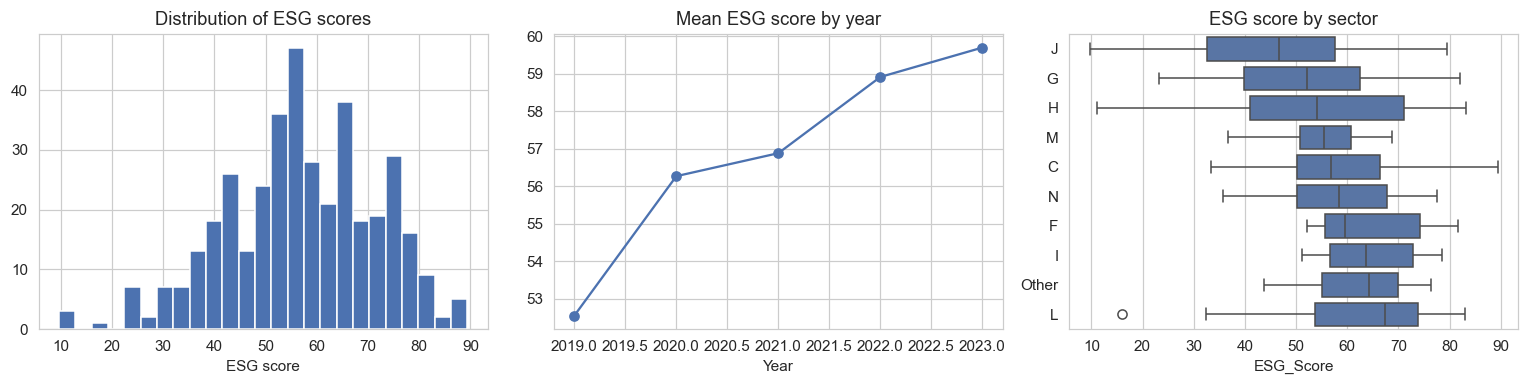

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

axes[0].hist(df[TARGET], bins=25, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of ESG scores'); axes[0].set_xlabel('ESG score')

yearly = df.groupby('Year')[TARGET].mean()
axes[1].plot(yearly.index, yearly.values, marker='o', color='#4C72B0')
axes[1].set_title('Mean ESG score by year'); axes[1].set_xlabel('Year')

order = df.groupby('SectorGrouped')[TARGET].median().sort_values().index
sns.boxplot(data=df, y='SectorGrouped', x=TARGET, order=order, ax=axes[2], color='#4C72B0')
axes[2].set_title('ESG score by sector'); axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig(OUT / 'figure_4_1_distributions.png')
plt.show()

---
## 3. Correlation analysis and multicollinearity: **Table 4.2**

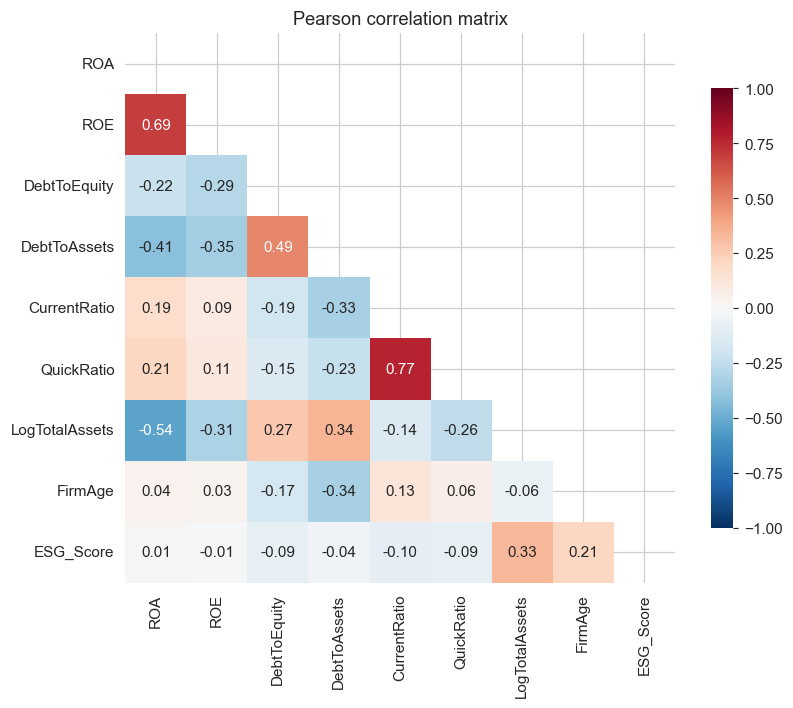

In [42]:
corr = df[RATIOS + CONTROLS + [TARGET]].corr()

plt.figure(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink': .8})
plt.title('Pearson correlation matrix')
plt.tight_layout()
plt.savefig(OUT / 'figure_4_2_correlation.png')
plt.show()

corr.round(3).to_csv(OUT / 'table_4_2_correlations.csv')

In [43]:
# Bivariate correlations with the dependent variable
biv = corr[TARGET].drop(TARGET).sort_values()
print('Correlation with ESG score:')
print(biv.round(3).to_string())

Correlation with ESG score:
CurrentRatio     -0.098
DebtToEquity     -0.094
QuickRatio       -0.090
DebtToAssets     -0.044
ROE              -0.014
ROA               0.009
FirmAge           0.213
LogTotalAssets    0.335


In [44]:
X_vif = sm.add_constant(df[RATIOS + CONTROLS])
vif = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif = vif[vif['Variable'] != 'const'].round(2)
vif.to_csv(OUT / 'table_4_3_vif.csv', index=False)

print('Variance inflation factors (values above 10 indicate a problem):')
print(vif.to_string(index=False))

Variance inflation factors (values above 10 indicate a problem):
      Variable  VIF
           ROA 2.60
           ROE 2.04
  DebtToEquity 1.39
  DebtToAssets 1.79
  CurrentRatio 2.71
    QuickRatio 2.63
LogTotalAssets 1.57
       FirmAge 1.15


---
## 4. Build the model matrix

In [45]:
sector_dummies = pd.get_dummies(df['SectorGrouped'], prefix='Sec', drop_first=True).astype(float)
year_dummies   = pd.get_dummies(df['Year'], prefix='Yr', drop_first=True).astype(float)

X = pd.concat([df[RATIOS + CONTROLS], sector_dummies, year_dummies], axis=1)
y = df[TARGET]
groups = df['ISIN']

# Standardise continuous predictors only; dummies remain 0/1
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[RATIOS + CONTROLS] = scaler.fit_transform(X[RATIOS + CONTROLS])

print(f'Design matrix: {X_scaled.shape[0]} observations × {X_scaled.shape[1]} features')
print(f'  {len(RATIOS)} ratios, {len(CONTROLS)} controls, '
      f'{sector_dummies.shape[1]} sector dummies, {year_dummies.shape[1]} year dummies')

Design matrix: 389 observations × 21 features
  6 ratios, 2 controls, 9 sector dummies, 4 year dummies


### 4.1 Grouped train/test split

The split is stratified by firm, not by observation. Every year of a given company falls
entirely on one side of the partition.

In [46]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_scaled, y, groups=groups))

X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train = groups.iloc[train_idx]

assert set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]) == set(), 'Firm overlap detected'

print(f'Train : {len(train_idx):>3} obs, {g_train.nunique():>2} firms')
print(f'Test  : {len(test_idx):>3} obs, {groups.iloc[test_idx].nunique():>2} firms')
print('No firm appears in both partitions.')

Train : 314 obs, 68 firms
Test  :  75 obs, 17 firms
No firm appears in both partitions.


In [47]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'R²':    r2_score(y_true, y_pred),
        'RMSE':  np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':   mean_absolute_error(y_true, y_pred),
    }

results = []

---
## 5. Model 1: Multiple Linear Regression (baseline)

Fitted with `statsmodels` to obtain coefficients, standard errors, and p-values, which
address H1–H3 directly.

In [48]:
ols = sm.OLS(y_train, sm.add_constant(X_train)).fit()
mlr_pred = ols.predict(sm.add_constant(X_test))
results.append(evaluate('Multiple Linear Regression', y_test, mlr_pred))

print(ols.summary().tables[0])

                            OLS Regression Results                            
Dep. Variable:              ESG_Score   R-squared:                       0.322
Model:                            OLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     6.610
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           2.41e-15
Time:                        05:25:40   Log-Likelihood:                -1205.4
No. Observations:                 314   AIC:                             2455.
Df Residuals:                     292   BIC:                             2537.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         


In [49]:
def stars(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

coef_table = pd.DataFrame({
    'Coefficient': ols.params,
    'Std. Error':  ols.bse,
    't':           ols.tvalues,
    'p-value':     ols.pvalues,
}).loc[RATIOS + CONTROLS].round(4)
coef_table['Sig.'] = coef_table['p-value'].apply(stars)
coef_table.to_csv(OUT / 'table_4_4_mlr_coefficients.csv')

print('MLR coefficients on standardised predictors')
print('(a one-SD increase in the predictor changes the ESG score by the coefficient)')
print()
print(coef_table.to_string())
print()
print('*** p<0.01, ** p<0.05, * p<0.10')

MLR coefficients on standardised predictors
(a one-SD increase in the predictor changes the ESG score by the coefficient)

                Coefficient  Std. Error       t  p-value Sig.
ROA                  4.3368      1.1517  3.7655   0.0002  ***
ROE                 -1.0480      1.0974 -0.9550   0.3404     
DebtToEquity        -2.7177      0.8840 -3.0745   0.0023  ***
DebtToAssets         0.7642      1.0480  0.7292   0.4665     
CurrentRatio        -4.7680      1.2646 -3.7705   0.0002  ***
QuickRatio           3.1775      1.2929  2.4577   0.0146   **
LogTotalAssets       6.6288      1.0044  6.5995   0.0000  ***
FirmAge              1.9149      0.7454  2.5689   0.0107   **

*** p<0.01, ** p<0.05, * p<0.10


---
## 6. Models 2 and 3: Random Forest and XGBoost

Hyperparameters are tuned by randomised search within **grouped** cross-validation folds
drawn from the training partition only, so no test-partition information influences model
selection.

In [50]:
gkf_tune = GroupKFold(n_splits=5)

rf_grid = {
    'n_estimators':     [300, 500],
    'max_depth':        [3, 5, 8, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features':     ['sqrt', 0.5, 1.0],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid, n_iter=20, scoring='r2',
    cv=list(gkf_tune.split(X_train, y_train, groups=g_train)),
    random_state=RANDOM_STATE, n_jobs=-1)

rf_search.fit(X_train, y_train)
rf = rf_search.best_estimator_

print('Random Forest — best parameters:')
for k, v in rf_search.best_params_.items():
    print(f'  {k:<18} {v}')
print(f'  grouped CV R²      {rf_search.best_score_:.4f}')

Random Forest — best parameters:
  n_estimators       300
  min_samples_leaf   1
  max_features       sqrt
  max_depth          3
  grouped CV R²      -0.0310


In [51]:
xgb_grid = {
    'n_estimators':     [200, 500],
    'learning_rate':    [0.01, 0.05, 0.10],
    'max_depth':        [2, 3, 4, 6],
    'subsample':        [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'min_child_weight': [1, 5, 10],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    xgb_grid, n_iter=25, scoring='r2',
    cv=list(gkf_tune.split(X_train, y_train, groups=g_train)),
    random_state=RANDOM_STATE, n_jobs=-1)

xgb_search.fit(X_train, y_train)
xgb = xgb_search.best_estimator_

print('XGBoost — best parameters:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k:<18} {v}')
print(f'  grouped CV R²      {xgb_search.best_score_:.4f}')

XGBoost — best parameters:
  subsample          0.9
  n_estimators       200
  min_child_weight   1
  max_depth          6
  learning_rate      0.01
  colsample_bytree   0.9
  grouped CV R²      0.0280


In [52]:
results.append(evaluate('Random Forest', y_test, rf.predict(X_test)))
results.append(evaluate('XGBoost',       y_test, xgb.predict(X_test)))

comparison = pd.DataFrame(results).round(4)
comparison.to_csv(OUT / 'table_4_5_model_comparison.csv', index=False)

print('Held-out test performance (grouped split)')
print(comparison.to_string(index=False))

Held-out test performance (grouped split)
                     Model      R²    RMSE     MAE
Multiple Linear Regression  0.2392 14.2752 12.0156
             Random Forest -0.0678 16.9112 13.0730
                   XGBoost  0.0336 16.0885 12.7571


---
## 7. Why the split design matters

This section demonstrates the consequence of ignoring the panel structure. The identical
models are re-fitted using a conventional random split, in which the same firm may appear
in both training and test data.

This is presented as a methodological diagnostic, not as a result.

In [53]:
Xtr_n, Xte_n, ytr_n, yte_n = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE)

naive = []
for name, model in [('Multiple Linear Regression', LinearRegression()),
                    ('Random Forest', RandomForestRegressor(**rf_search.best_params_,
                                                            random_state=RANDOM_STATE, n_jobs=-1)),
                    ('XGBoost', XGBRegressor(**xgb_search.best_params_,
                                             random_state=RANDOM_STATE, n_jobs=-1))]:
    model.fit(Xtr_n, ytr_n)
    naive.append(evaluate(name, yte_n, model.predict(Xte_n)))

naive_df = pd.DataFrame(naive).round(4)

side_by_side = comparison[['Model', 'R²']].merge(
    naive_df[['Model', 'R²']], on='Model', suffixes=(' (grouped)', ' (random)'))
side_by_side['Inflation'] = (side_by_side['R² (random)'] - side_by_side['R² (grouped)']).round(4)
side_by_side.to_csv(OUT / 'table_4_6_leakage_diagnostic.csv', index=False)

print('Effect of ignoring panel structure')
print(side_by_side.to_string(index=False))

Effect of ignoring panel structure
                     Model  R² (grouped)  R² (random)  Inflation
Multiple Linear Regression        0.2392       0.2272    -0.0120
             Random Forest       -0.0678       0.2101     0.2779
                   XGBoost        0.0336       0.4499     0.4163


In [54]:
within  = df.groupby('ISIN')[TARGET].std().mean()
between = df.groupby('ISIN')[TARGET].mean().std()

print(f'Mean within-firm SD of ESG score : {within:.2f}')
print(f'Between-firm SD of ESG score     : {between:.2f}')
print(f'Ratio                            : {between/within:.1f}×')
print()
print('ESG scores vary far more across firms than within them over time.')
print('Under a random split, tree models can identify the firm from its financial')
print('profile and reproduce a score already seen in training.')

Mean within-firm SD of ESG score : 5.37
Between-firm SD of ESG score     : 13.81
Ratio                            : 2.6×

ESG scores vary far more across firms than within them over time.
Under a random split, tree models can identify the firm from its financial
profile and reproduce a score already seen in training.


---
## 8. Cross-validated performance: **Table 4.7**

Ten-fold grouped cross-validation across the full sample, providing a more stable estimate
than a single train/test split.

In [55]:
gkf10 = GroupKFold(n_splits=10)
folds = list(gkf10.split(X_scaled, y, groups=groups))

cv_rows = []
for name, model in [('Multiple Linear Regression', LinearRegression()),
                    ('Random Forest', RandomForestRegressor(**rf_search.best_params_,
                                                            random_state=RANDOM_STATE, n_jobs=-1)),
                    ('XGBoost', XGBRegressor(**xgb_search.best_params_,
                                             random_state=RANDOM_STATE, n_jobs=-1))]:
    r2  = cross_val_score(model, X_scaled, y, cv=folds, scoring='r2')
    mae = -cross_val_score(model, X_scaled, y, cv=folds, scoring='neg_mean_absolute_error')
    cv_rows.append({'Model': name,
                    'CV R² (mean)': r2.mean(), 'CV R² (SD)': r2.std(),
                    'CV MAE (mean)': mae.mean()})

cv_df = pd.DataFrame(cv_rows).round(4)
cv_df.to_csv(OUT / 'table_4_7_cross_validation.csv', index=False)
print('Ten-fold grouped cross-validation')
print(cv_df.to_string(index=False))

Ten-fold grouped cross-validation
                     Model  CV R² (mean)  CV R² (SD)  CV MAE (mean)
Multiple Linear Regression       -0.2584      0.8011        11.2723
             Random Forest       -0.0122      0.2311        11.0249
                   XGBoost       -0.1608      0.5575        11.3005


---
## 9. SHAP interpretability **Figure 4.3**

SHAP values are computed for the better-performing ensemble model, decomposing each
prediction into the marginal contribution of every feature.

In [56]:
rf_r2  = comparison.loc[comparison.Model == 'Random Forest', 'R²'].iloc[0]
xgb_r2 = comparison.loc[comparison.Model == 'XGBoost', 'R²'].iloc[0]

best_model, best_name = (rf, 'Random Forest') if rf_r2 >= xgb_r2 else (xgb, 'XGBoost')
print(f'Computing SHAP values for: {best_name}')

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

Computing SHAP values for: XGBoost


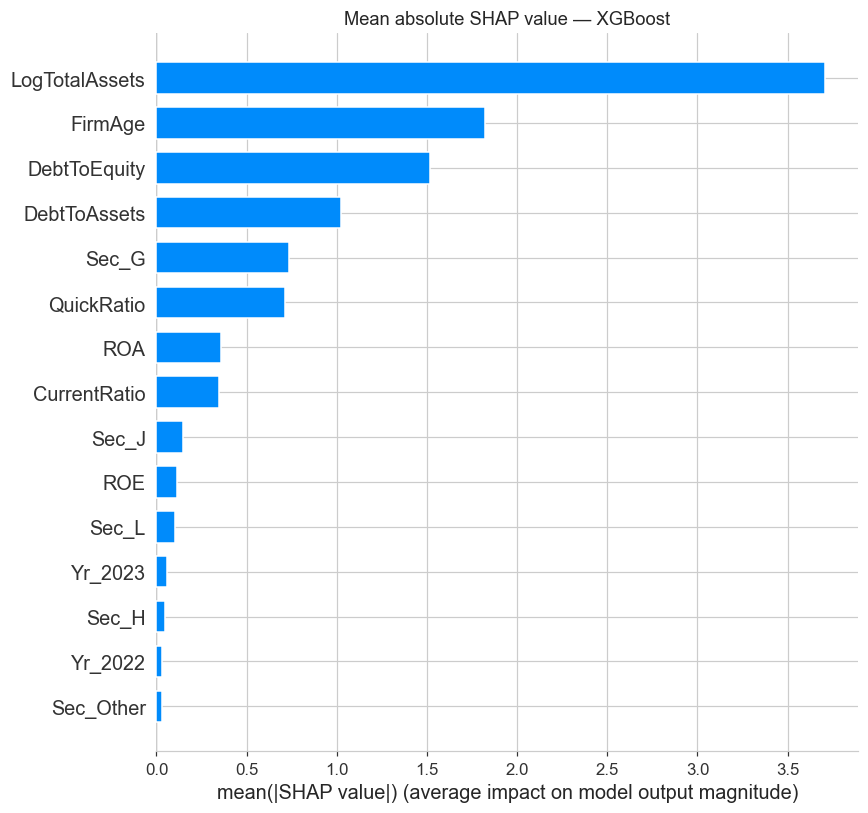

In [57]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
plt.title(f'Mean absolute SHAP value — {best_name}')
plt.tight_layout()
plt.savefig(OUT / 'figure_4_3_shap_importance.png')
plt.show()

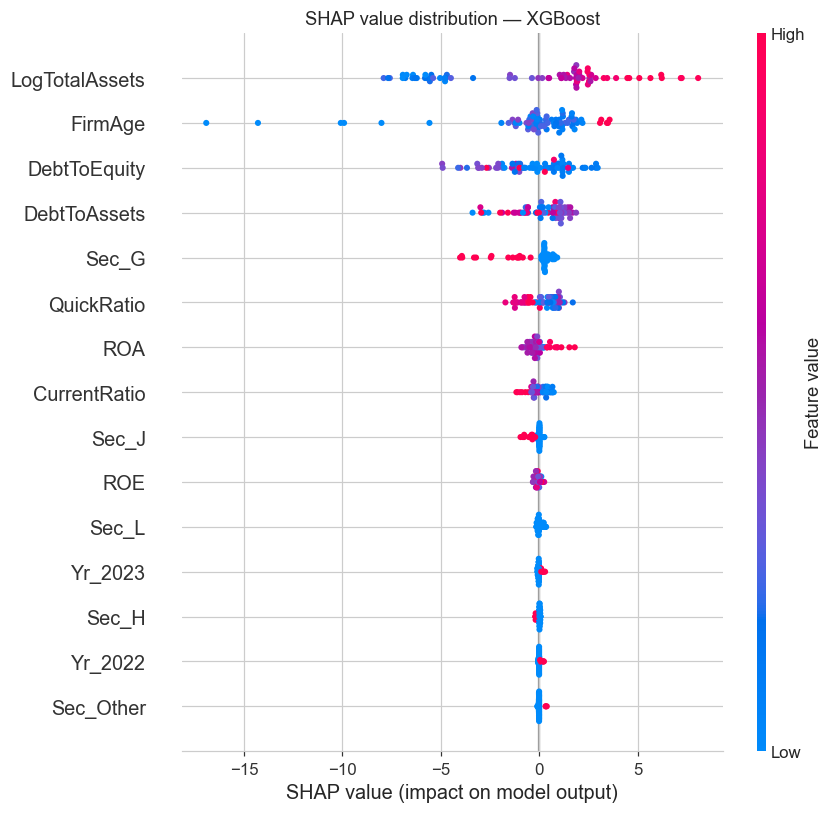

In [58]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title(f'SHAP value distribution — {best_name}')
plt.tight_layout()
plt.savefig(OUT / 'figure_4_4_shap_beeswarm.png')
plt.show()

In [59]:
shap_imp = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).round(3)

shap_imp.to_csv(OUT / 'table_4_8_shap_importance.csv', index=False)
print(shap_imp.head(12).to_string(index=False))

       Feature  Mean |SHAP|
LogTotalAssets        3.705
       FirmAge        1.824
  DebtToEquity        1.517
  DebtToAssets        1.021
         Sec_G        0.733
    QuickRatio        0.714
           ROA        0.360
  CurrentRatio        0.349
         Sec_J        0.148
           ROE        0.113
         Sec_L        0.105
       Yr_2023        0.056


---
## 10. Hypothesis verdicts: **Table 4.9**

H1–H3 are assessed on the sign and statistical significance of the MLR coefficients, which
are estimated with controls for firm size, sector, and year. H4 is assessed by comparing
held-out and cross-validated performance across the three models.

In [63]:
def verdict(variables, expected_sign):
    lines = []
    for v in variables:
        b = coef_table.loc[v, 'Coefficient']
        p = coef_table.loc[v, 'p-value']
        sign_ok = (b > 0) if expected_sign == '+' else (b < 0)
        if p >= 0.10:
            outcome = 'not significant'
        else:
            outcome = 'supported' if sign_ok else 'significant, opposite sign'
        lines.append(f'{v}: β={b:+.3f}, p={p:.3f} → {outcome}')
    return lines

print('H1: Profitability positively associated with ESG')
for l in verdict(['ROA', 'ROE'], '+'): print('   ', l)
print()
print('H2: Leverage negatively associated with ESG')
for l in verdict(['DebtToEquity', 'DebtToAssets'], '-'): print('   ', l)
print()
print('H3: Liquidity positively associated with ESG')
for l in verdict(['CurrentRatio', 'QuickRatio'], '+'): print('   ', l)
print()
print('H4: Ensemble methods outperform MLR')
best_row = comparison.loc[comparison['R²'].idxmax()]
print(f"    Best held-out R²: {best_row['Model']} ({best_row['R²']:.4f})")
print(f"    Best CV R²      : {cv_df.loc[cv_df['CV R² (mean)'].idxmax(), 'Model']}")

H1: Profitability positively associated with ESG
    ROA: β=+4.337, p=0.000 → supported
    ROE: β=-1.048, p=0.340 → not significant

H2: Leverage negatively associated with ESG
    DebtToEquity: β=-2.718, p=0.002 → supported
    DebtToAssets: β=+0.764, p=0.467 → not significant

H3: Liquidity positively associated with ESG
    CurrentRatio: β=-4.768, p=0.000 → significant, opposite sign
    QuickRatio: β=+3.178, p=0.015 → supported

H4: Ensemble methods outperform MLR
    Best held-out R²: Multiple Linear Regression (0.2392)
    Best CV R²      : Random Forest


In [64]:
# Assemble the verdict table for Chapter 4
rows = []
for h, vars_, sign, statement in [
    ('H1', ['ROA', 'ROE'], '+', 'Profitability positively associated with ESG'),
    ('H2', ['DebtToEquity', 'DebtToAssets'], '-', 'Leverage negatively associated with ESG'),
    ('H3', ['CurrentRatio', 'QuickRatio'], '+', 'Liquidity positively associated with ESG'),
]:
    sig = [v for v in vars_ if coef_table.loc[v, 'p-value'] < 0.10]
    correct = [v for v in sig if (coef_table.loc[v, 'Coefficient'] > 0) == (sign == '+')]
    if not sig:
        outcome = 'Not supported'
    elif len(correct) == len(sig):
        outcome = 'Supported'
    elif correct:
        outcome = 'Mixed'
    else:
        outcome = 'Contradicted'
    detail = '; '.join(f"{v} β={coef_table.loc[v,'Coefficient']:+.2f}{stars(coef_table.loc[v,'p-value'])}"
                       for v in vars_)
    rows.append({'Hypothesis': h, 'Statement': statement, 'Evidence': detail, 'Verdict': outcome})

h4_supported = max(comparison.loc[comparison.Model != 'Multiple Linear Regression', 'R²']) > \
               comparison.loc[comparison.Model == 'Multiple Linear Regression', 'R²'].iloc[0]
rows.append({'Hypothesis': 'H4',
             'Statement': 'Ensemble models outperform MLR',
             'Evidence': '; '.join(f"{r['Model']} R²={r['R²']:.3f}" for _, r in comparison.iterrows()),
             'Verdict': 'Supported' if h4_supported else 'Not supported'})

verdicts = pd.DataFrame(rows)
verdicts.to_csv(OUT / 'table_4_9_hypothesis_verdicts.csv', index=False)
verdicts

,Hypothesis,Statement,Evidence,Verdict
0,H1,Profitability positively associated with ESG,ROA β=+4.34***; ROE β=-1.05,Supported
1,H2,Leverage negatively associated with ESG,DebtToEquity β=-2.72***; DebtToAssets β=+0.76,Supported
2,H3,Liquidity positively associated with ESG,CurrentRatio β=-4.77***; QuickRatio β=+3.18**,Mixed
3,H4,Ensemble models outperform MLR,Multiple Linear Regression R²=0.239; Random Fo...,Not supported


---
## 11. Final export: relabelling and file summary

Variable names are replaced with readable labels for presentation, and the
cross-validation and leakage diagnostic tables are renumbered to match the
order in which they are discussed in Chapter 4.

In [62]:
# Relabel exported tables and correct table numbering for the dissertation
LABELS = {
    'ROA': 'Return on assets',            'ROE': 'Return on equity',
    'DebtToEquity': 'Debt-to-equity',     'DebtToAssets': 'Debt-to-assets',
    'CurrentRatio': 'Current ratio',      'QuickRatio': 'Quick ratio',
    'LogTotalAssets': 'Log total assets', 'FirmAge': 'Firm age',
    'ESG_Score': 'ESG score',
    'Sec_F': 'Sector: Construction',   'Sec_G': 'Sector: Retail',
    'Sec_H': 'Sector: Transport',      'Sec_I': 'Sector: Hospitality',
    'Sec_J': 'Sector: ICT',            'Sec_L': 'Sector: Real estate',
    'Sec_M': 'Sector: Professional',   'Sec_N': 'Sector: Administrative',
    'Sec_Other': 'Sector: Other',
    'Yr_2020': 'Year 2020', 'Yr_2021': 'Year 2021',
    'Yr_2022': 'Year 2022', 'Yr_2023': 'Year 2023',
}

# Table 4.1 — descriptive statistics
t = desc.rename(index=LABELS).round(3); t.index.name = 'Variable'
t.to_csv(OUT / 'table_4_1_descriptives.csv')

# Table 4.2 — correlation matrix
t = corr.rename(index=LABELS, columns=LABELS).round(3); t.index.name = 'Variable'
t.to_csv(OUT / 'table_4_2_correlations.csv')

# Table 4.3 — variance inflation factors
t = vif.copy(); t['Variable'] = t['Variable'].replace(LABELS)
t.to_csv(OUT / 'table_4_3_vif.csv', index=False)

# Table 4.4 — MLR coefficients
t = coef_table.rename(index=LABELS); t.index.name = 'Variable'
t.to_csv(OUT / 'table_4_4_mlr_coefficients.csv')

# Table 4.8 — SHAP importance
t = shap_imp.copy(); t['Feature'] = t['Feature'].replace(LABELS)
t.to_csv(OUT / 'table_4_8_shap_importance.csv', index=False)

# Correct table numbering: cross-validation is discussed before the leakage diagnostic
cv_df.to_csv(OUT / 'table_4_6_cross_validation.csv', index=False)
side_by_side.to_csv(OUT / 'table_4_7_leakage_diagnostic.csv', index=False)
(OUT / 'table_4_7_cross_validation.csv').unlink(missing_ok=True)
(OUT / 'table_4_6_leakage_diagnostic.csv').unlink(missing_ok=True)

print('All tables relabelled and renumbered.')
for f in sorted(OUT.iterdir()):
    print(' ', f.name)

All tables relabelled and renumbered.
  .ipynb_checkpoints
  01_basic_network.html
  03_corporate_ownership_network.html
  04_network_by_employees.html
  04b_network_size_by_employees.html
  05_first10_employees.html
  06_first10_country.html
  07_first10_combined.html
  07a_full_network_degree.html
  08_top10_degree_network.html
  10_closeness_full_network.html
  11_top10_closeness_network.html
  12a_closeness_highlighted.html
  13_top10_betweenness_network.html
  14_betweenness_highlighted.html
  17_top10_eigenvector_network.html
  17a_eigenvector_highlighted.html
  figure_4_1_distributions.png
  figure_4_2_correlation.png
  figure_4_3_shap_importance.png
  figure_4_4_shap_beeswarm.png
  table_4_1_descriptives.csv
  table_4_2_correlations.csv
  table_4_3_vif.csv
  table_4_4_mlr_coefficients.csv
  table_4_5_model_comparison.csv
  table_4_6_cross_validation.csv
  table_4_7_leakage_diagnostic.csv
  table_4_8_shap_importance.csv
  table_4_9_hypothesis_verdicts.csv
